In [5]:
# Cell 1 - Imports & config
import numpy as np
import pandas as pd
from scipy import signal
from scipy.signal import periodogram
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Notebook settings
SAMPLING_RATE = 1000          # Hz (matches your earlier code)
WINDOW_SEC = 1.0              # window size in seconds (tweakable)
WINDOW_SAMPLES = int(WINDOW_SEC * SAMPLING_RATE)
OVERLAP = 0.5                 # 50% overlap
STEP = int(WINDOW_SAMPLES * (1 - OVERLAP))
RANDOM_STATE = 42


In [6]:
# Cell 2 - helper functions

def sliding_window(arr, win_size, step):
    """Generator of windows (start_idx, window_array)."""
    n = arr.shape[0]
    for start in range(0, n - win_size + 1, step):
        yield start, arr[start:start + win_size]

# Time-domain features commonly used in HAR/EMG scratch detection
def time_domain_features(win):
    # win: 1D numpy array
    mean = np.mean(win)
    std = np.std(win)
    mav = np.mean(np.abs(win))
    rms = np.sqrt(np.mean(win**2))
    wl = np.sum(np.abs(np.diff(win)))              # waveform length
    zc = ((win[:-1] * win[1:]) < 0).sum()         # zero crossings
    # simple slope sign changes
    ssc = np.sum(((np.diff(win[:-1]) * np.diff(win[1:])) < 0).astype(int))
    # min/max
    mn = win.min(); mx = win.max()
    return [mean, std, mav, rms, wl, zc, ssc, mn, mx]

def stft_band_energy(win, fs=SAMPLING_RATE, nperseg=256, noverlap=128, bands=None):
    """
    Compute STFT magnitude, then summarize band energies.
    bands: list of (low, high) Hz bands to summarize. if None, default bands used.
    returns list of band energies (log-scaled) and global spectral entropy & dominant freq.
    """
    if bands is None:
        bands = [(0,5), (5,20), (20,50), (50,120), (120,300)]  # example bands (tweakable)
    f, t, S = signal.stft(win, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=256, boundary='zeros')
    S_mag = np.abs(S)  # shape (freq_bins, time_frames)
    psd = np.mean(S_mag**2, axis=1) + 1e-12   # power per freq bin
    band_energies = []
    for (lo, hi) in bands:
        idx = np.where((f >= lo) & (f < hi))[0]
        if idx.size == 0:
            band_energies.append(0.0)
        else:
            band_energies.append(np.log10(np.sum(psd[idx]) + 1e-12))
    # spectral entropy
    p_norm = psd / psd.sum()
    spec_entropy = -np.sum(p_norm * np.log2(p_norm + 1e-12))
    # dominant frequency
    dom_freq = f[np.argmax(psd)]
    return band_energies + [spec_entropy, dom_freq]


In [7]:
import pandas as pd

file_name = "eczware_dataset.csv"  # your CSV file without headers
column_names = ["flex1", "flex2", "spec_ax", "spec_ay", "spec_az","label"]  # replace with your actual names

# Read the CSV without headers
df = pd.read_csv(file_name, header=None)

# Assign column names
df.columns = column_names

# Save it back (overwriting the original or as a new file)
df.to_csv(file_name, index=False)

print(f"Headers added and saved to {file_name}")


Headers added and saved to eczware_dataset.csv


In [8]:
# Cell 3 - load CSV & extract features into X, y
# Assumes CSV columns: flex1, flex2, spec_ax, spec_ay, spec_az, label
fname = "eczware_dataset.csv"   # change path if needed

# Because CSV is large (900k+ rows), use pandas to read in memory if you have RAM, else chunk.
df = pd.read_csv(fname)
print("CSV loaded. Rows:", len(df))

# convert columns to numeric arrays (force dtype)
f1_arr = df['flex1'].astype(float).to_numpy()
f2_arr = df['flex2'].astype(float).to_numpy()
ax_arr = df['spec_ax'].astype(float).to_numpy()
ay_arr = df['spec_ay'].astype(float).to_numpy()
az_arr = df['spec_az'].astype(float).to_numpy()
labels_raw = df['label'].to_numpy()

# scale flex same as prior code (3.3/65535) and accel conversion as prior script
f1_arr = f1_arr * 3.3 / 65535.0
f2_arr = f2_arr * 3.3 / 65535.0
ax_arr = (ax_arr - 32768) / 16384.0
ay_arr = (ay_arr - 32768) / 16384.0
az_arr = (az_arr - 32768) / 16384.0

# We'll build features per-window; X list and y list
X = []
y = []

for start, _ in sliding_window(f1_arr, WINDOW_SAMPLES, STEP):
    # pull window slices
    w_f1 = f1_arr[start:start+WINDOW_SAMPLES]
    w_f2 = f2_arr[start:start+WINDOW_SAMPLES]
    w_ax = ax_arr[start:start+WINDOW_SAMPLES]
    w_ay = ay_arr[start:start+WINDOW_SAMPLES]
    w_az = az_arr[start:start+WINDOW_SAMPLES]
    w_label_slice = labels_raw[start:start+WINDOW_SAMPLES]

    # label for window = majority label in that window
    counts = pd.Series(w_label_slice).value_counts()
    window_label = counts.idxmax()

    # time-domain features for flex sensors (two channels)
    feats = []
    feats += time_domain_features(w_f1)
    feats += time_domain_features(w_f2)

    # aggregate accel magnitude & then STFT summaries
    mag = np.sqrt(w_ax**2 + w_ay**2 + w_az**2)
    # time domain of magnitude
    feats += time_domain_features(mag)

    # add STFT band energies & spectral features from magnitude
    feats += stft_band_energy(mag)

    X.append(feats)
    y.append(window_label)

X = np.array(X)
y = np.array(y)
print("Windows extracted:", X.shape, "Labels distribution:", dict(pd.Series(y).value_counts()))


CSV loaded. Rows: 2700000
Windows extracted: (5399, 34) Labels distribution: {'scratch': np.int64(1800), 'rest': np.int64(1800), 'other': np.int64(1799)}


In [9]:
# Cell 4 - split and scale
# For a simple eval we do a stratified random split. If you have multiple subjects, prefer leave-one-subject-out.
from sklearn.model_selection import StratifiedShuffleSplit

# first split train+val / test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

# then split train / val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=RANDOM_STATE)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# optional PCA for dimensionality reduction (keeps 95% variance)
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_p = pca.fit_transform(X_train_scaled)
X_val_p   = pca.transform(X_val_scaled)
X_test_p  = pca.transform(X_test_scaled)
print("After PCA shape:", X_train_p.shape)


Shapes: (3900, 34) (689, 34) (810, 34)
After PCA shape: (3900, 9)


In [10]:
# Cell 5 - train KNN with GridSearch on k and distance metric (use PCA inputs)
param_grid = {'n_neighbors': [1,3,5,7,9,11], 'weights': ['uniform', 'distance'], 'p': [1,2]}
knn = KNeighborsClassifier()
gs = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs.fit(X_train_p, y_train)

print("Best params:", gs.best_params_, "Best CV score:", gs.best_score_)

best_knn = gs.best_estimator_

# Validation accuracy
y_val_pred = best_knn.predict(X_val_p)
val_acc = accuracy_score(y_val, y_val_pred)
print("Validation accuracy:", val_acc)

# Test accuracy
y_test_pred = best_knn.predict(X_test_p)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy:", test_acc)

# Detailed classification report
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred))


Best params: {'n_neighbors': 5, 'p': 2, 'weights': 'uniform'} Best CV score: 0.8733333333333334
Validation accuracy: 0.8548621190130624
Test accuracy: 0.8641975308641975

Classification report (test):
               precision    recall  f1-score   support

       other       0.79      0.81      0.80       270
        rest       0.98      0.97      0.98       270
     scratch       0.82      0.80      0.81       270

    accuracy                           0.86       810
   macro avg       0.86      0.86      0.86       810
weighted avg       0.86      0.86      0.86       810



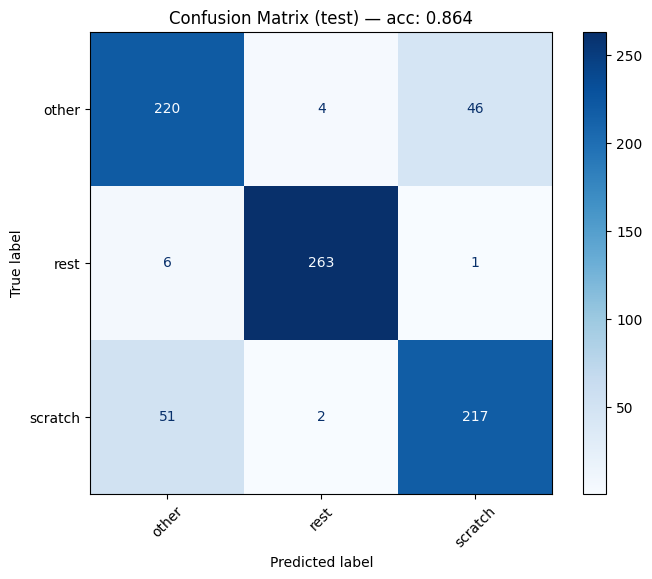

In [11]:
# Cell 6 - confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title(f"Confusion Matrix (test) — acc: {test_acc:.3f}")
plt.show()

In [12]:

import joblib

# Assuming your trained KNN model variable is named `knn`
joblib.dump(knn, "knn_model_2.keras")
print("Model saved as knn_model_2.keras")


Model saved as knn_model_2.keras
